<font size="+1"><b>Conteúdo:</b></font>
<ol>
  <li><a href="#introducao">Introdução</a></li>
  <li><a href="#face">Reconhecimento de Face com SVM</a></li>
  <li><a href="#suporte">Treinamento da SVM</a></li>
  <li><a href="#desafio">Desafio dos Óculos</a></li>
</ol>


<a id="introducao"></a>
# 1. Introdução

As **Máquinas de Vetores de Suporte** (*Support Vector Machines* - SVM) funcionam no reconhecimento de imagens <span style="color:red">convertendo a classificação visual em um problema de geometria em um espaço multidimensional</span>.

Para entender como esse algoritmo funciona, vamos usar uma comparação simples. Imagine que cada imagem do seu conjunto de dados é uma bolinha colorida espalhada sobre uma mesa. Bolinhas pretas representam uma categoria (por exemplo, fotos de gatos) e bolinhas brancas representam outra categoria (por exemplo, fotos de cachorros). A tarefa para o modelo de ML é encontrar uma forma de separar as bolinhas. Na Álgebra Linear, chamamos essa divisória de **hiperplano** — uma "linha" ou "parede" invisível que divide esse espaço.

<div align="center">
    <img src="./img/brancas_pretas.png" alt="Bolas brancas e bolas pretas." width=350>
</div>

<!--![Bolas brancas e bolas pretas.](./img/brancas_pretas.png)-->

As **Máquinas de Vetores de Suporte** (SVM's) são métodos de aprendizado supervisionado que tentam obter os hiperplanos de uma forma otimizada. As SVM's são métodos inteligentes que não cria qualquer divisória (hiperplano), mas busca a uma reta divisória perfeita, e elas o fazem **buscando a maior distância** entre as lacunas entre as instâncias de diferentes classes. O algoritmo procura o "corredor" mais largo e vazio entre as bolinhas pretas e brancas.

A "parede" divisória é colocada exatamente no meio desse corredor, garantindo a maior margem de segurança possível para que os dois grupos fiquem bem separados.

Depois que essa fronteira ideal é construída, o trabalho do modelo torna-se muito mais fácil: ao se apresentar uma imagem nova desconhecida ao modelo, o sistema verifica de qual lado da fronteira ela está para então ele predizer, com precisão, a qual categoria ela pertence.
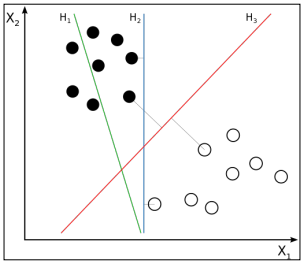

### 1.1 A Busca pela Divisória Perfeita
Seja o conjunto de dados composto por bolinhas pretas e bolinhas brancas espalhadas numa mesa (gráfico bidimensional). Cada cor representa uma categoria diferente, por exemplo, e-mails *spam* e e-mails normais (*ham*), ou peças com defeito e peças perfeitas.

O objetivo principal deste algoritmo, é desenhar uma reta (um hiperplano) capaz de separar perfeitamente estes dois mundos. Vamos analisar as três tentativas mostradas na figura anterior:

* **A Linha Verde ($H_1$)** - Modelo Falho: A reta corta o grupo das bolinhas pretas, deixando algumas do lado errado da divisória. Se usássemos este modelo, ele cometeria erros básicos de classificação.

* **A Linha Azul ($H_2$)** - Modelo Crítico (sem margens para erros): A reta consegue separar as bolinhas pretas das brancas, mas ela passa próxima a algumas bolinhas. Não há margem de segurança. Se o classificador receber um dado novo que fuja ligeiramente do padrão, há um risco enorme dele cair do lado errado da reta azul.

* **A Linha Vermelha ($H_3$)** - O Modelo Ideal: O algoritmo não apenas separa os grupos, mas procura encontrar a margem de segurança máxima. A reta vermelha passa exatamente no meio do "corredor" vazio que divide as bolinhas pretas e brancas. Ela mantém a maior distância possível das bolinhas mais próximas de cada lado.

#### A. Importância da <span style="color:rgb(200,0,0)">Reta Vermelha</span>  
A margem de segurança evita um problema muito comum em *Machine Learning* chamado *overfitting* (superajuste). Com uma margem ampla, o modelo não se limita a "decorar" a posição exata dos dados de treino. Em vez disso, ele torna-se robusto e muito bem preparado para classificar dados novos e desconhecidos com grande precisão.

#### B. Vetores de Suporte  
As linhas finas cinzentas, na figura anterior, ligam a reta vermelha às bolinhas (pretas e brancas) que estão mais próximas da divisória (fronteira). Estas bolinhas em questão, que estão no limite do "corredor", são chamadas de **Vetores de Suporte** (*Support Vectors*).  

O algoritmo usa apenas estes pontos críticos para desenhar a linha vermelha, ignorando todas as outras bolinhas que estão mais afastadas. É isto que torna o **SVM** tão eficiente e rápido, poupando imensa quantidade de memória do computador.

#### C. Truque das Dimensões Múltiplas (*Kernel Trick*)
E se os dados estivessem tão misturados que nenhuma reta conseguisse separá-los? O **SVM** resolve isso com uma manobra matemática chamada *Kernel Trick* (Truque do Núcleo). De forma simples, o **SVM** projeta esses dados para uma dimensão superior (como transformar um objeto plano num objeto 3D). Nessa nova dimensão, os dados reorganizam-se, permitindo que uma divisória simples separe tudo perfeitamente.

Com o pacote **Scikit-learn**, não precisamos fazer estes cálculos matemáticos, pois com apenas algumas linhas de código, pode-se encontrar a "reta vermelha" ideal, resolvendo problemas práticos e reais!

### 1.2 SVM na Prática
Etapas do **SVM**:

#### A. Transformação da Imagem em Números (vetores de pixels)
Para o algoritmo **SVM**, uma foto não é um rosto ou uma paisagem, é apenas um amontoado de números. Cada pontinho de cor (*pixel*) da imagem vira uma pista individual. Se você tiver uma foto minúscula de 64 x 64 *pixels*, o computador vai gerar um espaço de análise com 4.096 "direções" (dimensões). Os valores desses *pixels* são usados como entrada para o **SVM**, e a resposta que queremos descobrir (por exemplo, se a imagem é de um gato ou de um cachorro) é a nossa "classe alvo". É nesse espaço gigante de milhares de dimensões que as nossas "bolinhas" estão espalhadas.

#### B. Divisória Ótima (Margem Máxima)
O **SVM** desenha uma divisória (hiperplano) para separar as categorias. A grande sacada é que ele escolhe a divisória que cria o corredor mais largo e seguro entre as classes mais próximas. Ao garantir um espaço generoso entre as categorias, o modelo não fica "viciado" apenas nas instâncias conhecidas, evitando o problema do *overfitting*, tornando-se muito mais robusto e certeiro ao classificar uma foto desconhecida (não pertencente ao conjunto de dados do treinamento).

#### C. Truque de Mágica  (*Kernel Trick*)
Mas o que acontece se as bolinhas estiverem misturadas de um jeito que uma reta, ou uma parede, não consiga separá-las? (Imagine um anel de bolinhas azuis circulando um grupo de bolinhas vermelhas). Nessas situações usa-se o **truque do kernel**: é como se o algoritmo desse um "peteleco" nas bolinhas, jogando-as para o ar, criando uma nova dimensão. Com elas no ar, fica fácil passar uma folha plana entre as cores! O *kernel* remodela o espaço, permitindo que o **SVM** crie divisórias curvas e complexas de forma inteligente.

#### D. Eficiência no Uso de Memória
Mesmo lidando com milhares de dimensões e muitos dados, o **SVM** é considerado uma tecnologia eficiente. Ao construir a divisória, o modelo ignora quase todas as bolinhas e valoriza algumas poucas bolinhas que estão no limite do "corredor". <span style="color:red">Essas "bolinhas próximas à divisória" formam os **vetores de suporte**</span>.

Na prática, todo esse processo de classificação pode ser realizado de maneira simples, utilizando a classe **SVC** (*Support Vector Classifier*) do pacote **Scikit-learn**.

# <a id="face">2. Reconhecimento de Face com SVM</a>

Como as redes sociais conseguem sugerir o seu nome em uma foto que um amigo acabou de postar? O que parece mágica é apenas **Matemática** e ***Machine Learning*** em ação! Vamos aplicar o **SVM** para resolver o problema genérico de **Reconhecimento de Faces/Imagens**.

<div align="center">
    <img src="./img/face_rec.gif" alt="Imagem animada do processo de reconhecimento de faces." width="500px">
    <p>Fonte: Pinterest (br.pinterest.com)</p>
</div>

Para os humanos, uma foto é uma imagem clara de uma pessoa, ou de uma paisagem, ... Para a máquina, uma imagem é apenas uma grade gigante de pequenos pontos coloridos, chamados de *pixels*.

Vamos usar a intensidade da cor de cada *pixel* como uma "característica" (*feature*) para o modelo de aprendizagem de máquina. O objetivo é entregar uma foto de um rosto desconhecido ao algoritmo e pedir para ele predizer a pessoa (de uma lista conhecida) que tem o rosto apresentado.

<p style="color: red; font-style: italic;">
  Treinar um modelo SVM para reconhecimento de imagens exige muito processamento. Além disso, o algoritmo padrão não informa a "porcentagem de certeza" (ele apenas crava uma predição: "é a pessoa X", sem dizer o nível de incerteza da predição). Existem técnicas avançadas para contornar esse problema, tal como a Validação Cruzada, mas elas exigem ainda mais processamento computacional.
</p>

### 2.1 Conjunto de Dados  
O pacote **Scikit-learn** possui um conjunto de dados clássico, pronto para uso, chamado <span style="color:blue">**Olivetti Faces**</span>. Trata-se de conjunto de fotos de faces, tiradas entre Abr/1992 e Abr/1994, nos Laboratórios AT&T, em Cambridge, MA, EUA (créditos aos AT&T Laboratories Cambridge). A função `sklearn.datasets.fetch_olivetti_faces()` faz a busca desses dados para armazenamento das imagens da AT&T em memória *cache*. O conjunto tem 400 fotos de faces de 40 pessoas diferentes, com variadas expressões faciais (incluindo olhos abertos/fechados, sorrindo/não sorrindo, com óculos/sem óculos) e iluminação (fotos tiradas contra fundo homogêneo escuro, com as pessoas em posição ereta e frontal, com tolerância para algum movimento lateral).

In [1]:
# Importando e mostrando informações do conjunto de dados "Olivetti Faces"
import numpy as np
import matplotlib.pyplot as plt
import sklearn as skl

faces = skl.datasets.fetch_olivetti_faces()              # carregando o conjunto de dados da AT&T no objeto 'faces'
print("Primeira face:", faces.data[0], "\nFormato:", faces.data[0].shape)
print(faces.keys())
print(faces.DESCR)

Primeira face: [0.30991736 0.3677686  0.41735536 ... 0.15289256 0.16115703 0.1570248 ] 
Formato: (4096,)
dict_keys(['data', 'images', 'target', 'DESCR'])
.. _olivetti_faces_dataset:

The Olivetti faces dataset
--------------------------

`This dataset contains a set of face images`_ taken between April 1992 and
April 1994 at AT&T Laboratories Cambridge. The
:func:`sklearn.datasets.fetch_olivetti_faces` function is the data
fetching / caching function that downloads the data
archive from AT&T.

.. _This dataset contains a set of face images: https://cam-orl.co.uk/facedatabase.html

As described on the original website:

    There are ten different images of each of 40 distinct subjects. For some
    subjects, the images were taken at different times, varying the lighting,
    facial expressions (open / closed eyes, smiling / not smiling) and facial
    details (glasses / no glasses). All the images were taken against a dark
    homogeneous background with the subjects in an upright, fro

<div>
  ![alt text](faces-1.gif)
</div>

Informações sobre o conjunto de dados:  
* **faces.images**: Lista com as 400 fotos, no formato de matrizes com $64 \times 64$ pixels.  
* **faces.data**: As mesmas 400 fotos, mas "esticadas" em uma única linha de 4096 pixels ($64 \times 64 = 4096$) para cada foto. É nesse formato que o SVM manipula os dados.  
* **faces.target**: A classe alvo. Um valor de 0 a 39 que identifica quem é a pessoa da foto.

In [2]:
print(faces.keys())
print(faces.images.shape)
print(faces.data.shape)
print(faces.target.shape)

dict_keys(['data', 'images', 'target', 'DESCR'])
(400, 64, 64)
(400, 4096)
(400,)


### 2.2 Normalização do Dados (Escalonamento)  
Os algoritmos de *Machine Learning* funcionam melhor quando os dados estão na mesma escala. Com imagens, isso é crucial. Geralmente, cada *pixel* é armazenado em um byte (variando de 0 a 255). No presente caso, podemos verificar, executando o seguinte trecho, que nossas imagens já vêm como valores reais numa faixa uniforme entre 0 e 1 (valor do *pixel*):

In [3]:
# Verificando os valores mínimo, máximo e a média dos pixels
print("Valor Máximo:", np.max(faces.data))
print("Valor Mínimo:", np.min(faces.data))
print("Média:       ", np.mean(faces.data))
print("Pixels:      \n", faces.data)

Valor Máximo: 1.0
Valor Mínimo: 0.0
Média:        0.5470426
Pixels:      
 [[0.30991736 0.3677686  0.41735536 ... 0.15289256 0.16115703 0.1570248 ]
 [0.45454547 0.47107437 0.5123967  ... 0.15289256 0.15289256 0.15289256]
 [0.3181818  0.40082645 0.49173555 ... 0.14049587 0.14876033 0.15289256]
 ...
 [0.5        0.53305787 0.607438   ... 0.17768595 0.14876033 0.19008264]
 [0.21487603 0.21900827 0.21900827 ... 0.57438016 0.59090906 0.60330576]
 [0.5165289  0.46280992 0.28099173 ... 0.35950413 0.3553719  0.38429752]]


### 2.3 Álbum de Fotos  
Antes de colocar a inteligência artificial para aprender, é sempre bom "olharmos" os dados mais de perto... Vamos criar uma função auxiliar que usa a biblioteca **matplotlib** para imprimir um pequeno álbum com as faces em questão:

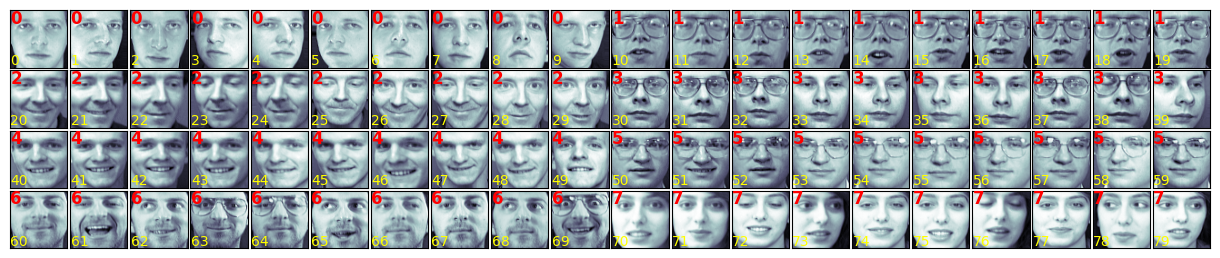

In [ ]:
def print_faces(images, target, top_n):
    ''' Função auxiliar para mostrar o conjunto de ddos de faces da Ollivetti. '''    
    fig = plt.figure(figsize=(12, 12))                      # tamanho do "mural de faces" (polegadas)
    fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)
    
    for i in range(top_n):
        p = fig.add_subplot(20, 20, i + 1,                  # espaço para cada foto (grid imaginário de 20x20)
                            xticks=[], yticks=[])
        p.imshow(images[i], cmap=plt.cm.bone)               # mostra imagem em tons de cinza 
        # Anotações (por cima da foto):
        p.text(0, 14, str(target[i]), color='red',          #  rotula imagem com classe alvo
                          fontsize=12, fontweight='bold') 
        p.text(0, 60, str(i), color='yellow', fontsize=10)  # posição da foto no conj. de dados

# Primeiras 80 fotos do banco de faces
print_faces(faces.images, faces.target, 80)

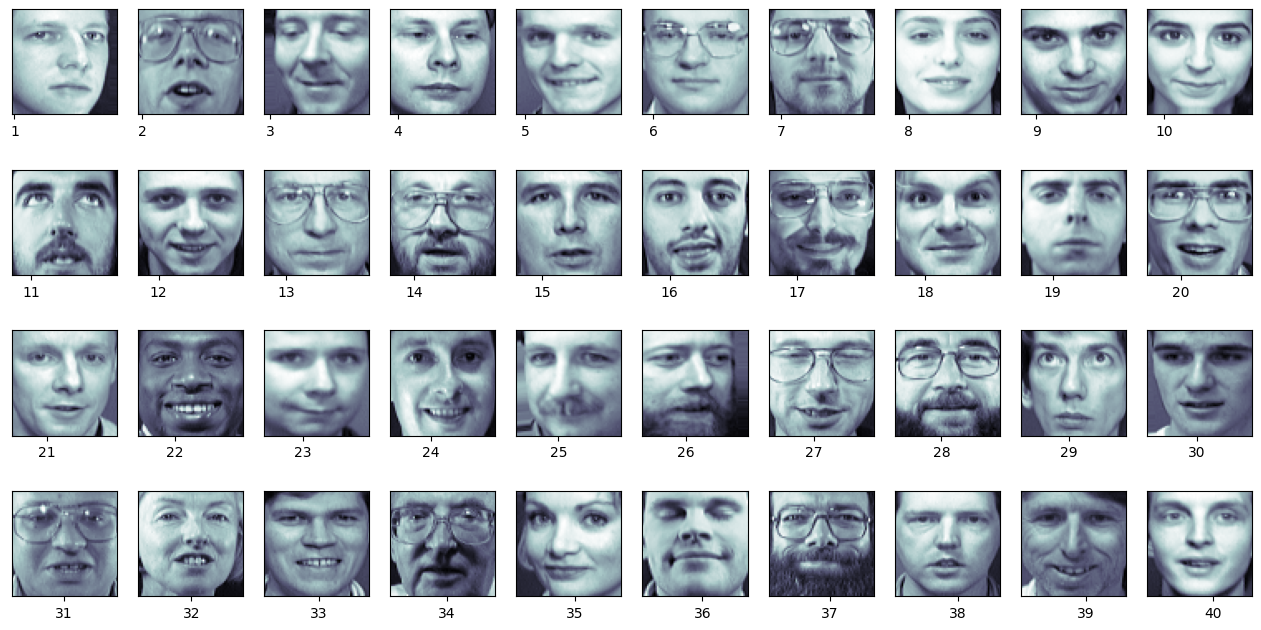

In [19]:
# Álbum de fotos das 40 distintas pessoas/faces
fig = plt.figure(figsize=(16, 8))
for i in range(40):
    ax = fig.add_subplot(4, 10, i+1, xticks=[i+1], yticks=[])
    ax.imshow(faces.images[i*10+4], cmap=plt.cm.bone)

# <a id="suporte">3. Treinamento da SVM</a>
Vamos usar a classe **SVC** (*Support Vector Classifier*) para obter a "linha divisória ideal" no caso de reconhecimento de faces.

Um dos parâmetros mais importantes do **SVC** é o *Kernel*. O *Kernel* é uma espécie de "estratégia de projeto" da **reta divisória**. Para começar, vamos usar o *kernel* **'linear'**, ou seja, vamos tentar separar as faces com retas simples.

In [ ]:
from sklearn.svm import SVC      # classificador SVM

# Cria um classificador SVC linear
svc = SVC(kernel='linear')       # o kernel default é o núcleo não linear 'rbf'

### A. Separando Materiais "de Estudo" e "de Prova"
Geralmente na escola, o professor não repete na prova os mesmos exercícios resolvidos em sala de aulas, certo? Ele quer testar se os alunos aprenderam o conceito, e não apenas se decoraram as respostas.

Em *Machine Learning* fazemos algo semelhante: pegamos os dados e separamos uma parte para o modelo "estudar" (treino) e outra parte para usar na "prova" (teste).

In [23]:
from sklearn.model_selection import train_test_split

# Separando 75% dos dados para treino e 25% para teste
X_treino, X_teste, y_treino, y_teste = train_test_split(faces.data, faces.target, test_size=0.25, random_state=0)

### B. Validação Cruzada (Lista de Exercícios)
Para ter certeza de que o modelo **SVM** está aprendendo bem, podemos aplicar a técnica chamada **Validação Cruzada** (*Cross-Validation*) ao classificador criado. Novamente, relacionando o conceito da **Validação Cruzada** com a Escola, podemos dizer que é como a resolução de uma lista de exercícios escolhidos aleatoriamente pelo professor, para ter uma nota (métrica de avaliação) que estime a compreensão de cada aluno da turma.

In [24]:
from sklearn.model_selection import cross_val_score, KFold
from scipy.stats import sem
import numpy as np

def avalia_validacao_cruzada(clf, X, y, K):
    cv = KFold(n_splits=K, shuffle=True, random_state=0)    # divide os dados em conj. de treino e conj. de teste
    score = cross_val_score(clf, X, y, cv=cv)               # treina e avalia o modelo de classificação (clf) K vezes
    print(f"Notas dos {K} testes: {score}")
    print(f"Média final: {np.mean(score):.3f} (+/- {sem(score):.3f})")

# Vamos aplicar 5 testes no nosso modelo de treino!
avalia_validacao_cruzada(svc, X_treino, y_treino, 5)

Notas dos 5 testes: [0.93333333 0.86666667 0.91666667 0.93333333 0.91666667]
Média final: 0.913 (+/- 0.012)


### C. Avaliação do Desempenho Real
Vamos criar uma função que ensina (treina) o modelo, aplica a prova (avaliação do aprendizado) e nos dá um relatório completo: a **Matriz de Confusão** e o **Relatório de Classificação**.

In [25]:
from sklearn import metrics

def treina_e_avalia(clf, X_train, X_test, y_train, y_test):
    # Fase de Estudo (Aprendizado): modelo associa as características às faces
    clf.fit(X_train, y_train)
    
    print(f"Acurácia no Treino (Estudo): {clf.score(X_train, y_train):.2f}")
    print(f"Acurácia no Teste  (Prova) : {clf.score(X_test, y_test):.2f}\n")
    
    # Faz as previsões com dados nunca vistos
    y_prev = clf.predict(X_test)
    
    print("Relatório de Classificação:")
    print(metrics.classification_report(y_test, y_prev))
    
    print("Matriz de Confusão:")
    print(metrics.confusion_matrix(y_test, y_prev))

# Treinamento e avaliação
treina_e_avalia(svc, X_treino, X_teste, y_treino, y_teste)

Acurácia no Treino (Estudo): 1.00
Acurácia no Teste  (Prova) : 0.99

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.86      1.00      0.92         6
           1       1.00      1.00      1.00         4
           2       1.00      1.00      1.00         2
           3       1.00      1.00      1.00         1
           4       1.00      1.00      1.00         1
           5       1.00      1.00      1.00         5
           6       1.00      1.00      1.00         4
           7       1.00      0.67      0.80         3
           9       1.00      1.00      1.00         1
          10       1.00      1.00      1.00         4
          11       1.00      1.00      1.00         1
          12       1.00      1.00      1.00         2
          13       1.00      1.00      1.00         3
          14       1.00      1.00      1.00         5
          15       1.00      1.00      1.00         3
          17       1.00      1.00     

<a id="desafio"></a>
# 4. Desafio dos Óculos
Em vez de apenas adivinhar quem é a pessoa da foto, vamos fazer uma pergunta mais difícil ao algoritmo: "Esta pessoa está usando óculos ou não?"

Primeiro, precisamos criar um novo gabarito. Vamos avisar ao computador quais fotos (pelos seus índices) mostram pessoas de óculos. As faces que tiverem óculos formarão a classe 1, as demais formarão a clasee 0.

In [26]:
# Índices conhecidos das fotos com óculos
oculos = [
            (10, 19),   (30, 32),   (37, 38),   (50, 59),   (63, 64),
            (69, 69),   (120, 121), (124, 129), (130, 139), (160, 161),
            (164, 169), (180, 182), (185, 185), (189, 189), (190, 192),
            (194, 194), (196, 199), (260, 269), (270, 279), (300, 309),
            (330, 339), (358, 359), (360, 369)
]

def cria_alvo(segmentos):
    y = np.zeros(faces.target.shape[0]) # cria lista vazia preenchida com ZEROS (classe 'sem óculos')
    for (inicio, fim) in segmentos:     # coloca UM (clasee 'com óculos') apenas nos índices informados
        y[inicio:fim + 1] = 1
    return y

alvo_oculos = cria_alvo(oculos)         # Cria um novo gabarito, focado apenas em faces com óculos

# Separando novamente conj. de treino e de teste para o novo gabarito
X_treino, X_teste, y_treino, y_teste = train_test_split(faces.data, alvo_oculos, test_size=0.25, random_state=0)

# Treinando um novo modelo para a nova tarefa
svc_oculos = SVC(kernel='linear')
treina_e_avalia(svc_oculos, X_treino, X_teste, y_treino, y_teste)

Acurácia no Treino (Estudo): 1.00
Acurácia no Teste  (Prova) : 0.99

Relatório de Classificação:
              precision    recall  f1-score   support

         0.0       1.00      0.99      0.99        67
         1.0       0.97      1.00      0.99        33

    accuracy                           0.99       100
   macro avg       0.99      0.99      0.99       100
weighted avg       0.99      0.99      0.99       100

Matriz de Confusão:
[[66  1]
 [ 0 33]]


### A. Avaliando a Performance do Modelo  
A acurácia do modelo treinado é excelente (quase 100%). Mas surge uma dúvida perigosa: será que o algoritmo aprendeu a reconhecer o formato de uma armação de óculos, ou será que ele simplesmente decorou as faces das pessoas que usam óculos nesse conjunto de dados?

Para fazer a **prova real**, vamos realizar um experimento rigoroso:  
* Vamos isolar as imagens da face da pessoa número 3 (índices de 30 a 39). Sabemos que essa pessoa tirou algumas fotos com óculos e outras sem óculos.
* Vamos treinar o modelo usando todas as outras pessoas. O algoritmo não vai ver o rosto da pessoa 3 durante o treino.
* A prova final será feita apenas com as fotos da face da pessoa 3.

Se o modelo acertar, saberemos que ele realmente aprendeu o conceito universal de "usar óculos", e não apenas decorou os rostos conhecidos!

<div align="center">  
    <img src="./img/face_30.png" alt="10 fotos da face de uma pessoa com e sem óculos, dipostas horizontalmete, lado a lado." width="500px">
</div>
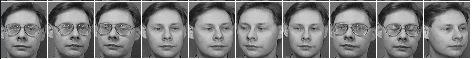

In [27]:
# Separa os dados da prova final: apenas as fotos da pessoa com índices 30 ao 39
X_teste_rigoroso = faces.data[30:40]
y_teste_rigoroso = alvo_oculos[30:40]

# Separa o material de treino (todas as outras fotos, excluindo as da pessoa 3)
selecionados = np.ones(alvo_oculos.shape[0])        # vetor preenchido com UM's
selecionados[30:40] = 0                             # pessoa selecionada
X_treino_rigoroso = faces.data[selecionados == 1]
y_treino_rigoroso = alvo_oculos[selecionados == 1]

# Cria e testa o modelo à prova de 'decoreba'
svc_prova_real = SVC(kernel='linear')
treina_e_avalia(svc_prova_real, X_treino_rigoroso, X_teste_rigoroso, y_treino_rigoroso, y_teste_rigoroso)

Acurácia no Treino (Estudo): 1.00
Acurácia no Teste  (Prova) : 0.90

Relatório de Classificação:
              precision    recall  f1-score   support

         0.0       0.83      1.00      0.91         5
         1.0       1.00      0.80      0.89         5

    accuracy                           0.90        10
   macro avg       0.92      0.90      0.90        10
weighted avg       0.92      0.90      0.90        10

Matriz de Confusão:
[[5 0]
 [1 4]]


### B. Diminuição da Performance do Modelo
Para vermos com os nossos próprios olhos quais foram as imagens que falharam, precisamos de preparar os dados para visualização. Lembram-se de que tínhamos "esticado" as imagens originais para uma única linha de 4096 *píxeis* para facilitar a leitura pro SVM? O **matplotlib** precisa da estrutura matricial original para mostrar a face. Por isso, usaremos a função **reshape** (pacote Numpy) para devolver as imagens ao formato de matriz (64 x 64 *píxels*).

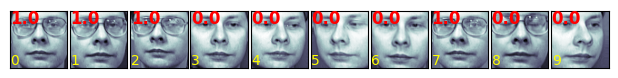

In [28]:
# Fazendo as previsões com o modelo no nosso teste rigoroso
y_prev = svc_prova_real.predict(X_teste_rigoroso)

# Reconstruindo as imagens (de uma linha de 4096 para uma grade 64 x 64)
faces_avaliadas = [np.reshape(x, (64, 64)) for x in X_teste_rigoroso]

# Imprimindo o resultado visual com a função que criámos anteriormente
print_faces(faces_avaliadas, y_prev, 10)

Ao executar o código da célula anterior e olhar para a imagem número 8 gerada no painel, percebe-se rapidamente o motivo da falha. Ela foge ao padrão das restantes fotografias com óculos: a borda da armação é praticamente invisível, a iluminação não ajuda e a pessoa está de olhos fechados. O algoritmo sentiu exatamente a mesma dificuldade que um humano teria numa análise rápida!

### C. Próximo Passo
Neste teste extremamente difícil, o modelo acertou 9 de 10 fotos! Apenas uma foto foi classificada incorretamente (como não tendo óculos, quando na verdade tinha). Se você investigar a imagem que o algoritmo errou, perceberá que a iluminação estava péssima, a borda da armação estava invisível e a pessoa estava de olhos fechados.

Esse resultado é muito animador para um modelo construído em tão poucas linhas de código. Contudo, em problemas reais muito mais complexos, o modelo linear básico pode falhar. É aí que entramos no mundo da afinação: testar novos *kernels* (como **poly** ou **rbf**) e ajustar parâmetros como **C** e **gamma** para encontrar a precisão máxima.

# Fontes

1. Garreta, R. & Moncecchi, G.; "Learning scikit-learn: Machine Learning in Python"; 2013; Packt Publishing.  

1. altunokelif (github id); "The Ollivetti Faces Dataset"; 11/01/2020; https://github.com/altunokelif/Face_recognition